In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load Dataset

In [2]:

path = r"F:\SFI\EDA\Data\retail_sales_dataset.csv"
df = pd.read_csv(path)


# Clean, Prepare & Dataset Analysis

In [3]:
print("--- INITIAL DATA INSPECTION ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

--- INITIAL DATA INSPECTION ---
Total Rows: 1000, Total Columns: 9

Missing Values per Column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


### 1. Convert Date into Datetime

In [4]:
# date in str so we convert into the datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


### 2. Duplicate Transactions Check & Removal

In [5]:
initial_rows = len(df)
df = df.drop_duplicates(subset=['Transaction ID'])
rows_after_dup = len(df)
print(f"\nDuplicates Removed: {initial_rows - rows_after_dup}")


Duplicates Removed: 0


### 3. Text Columns Normalization

In [6]:
# data me str colum ko strip karke start and last ke extra space ko hata rahe haii 

string_columns = ['Gender', 'Product Category']
for col in string_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

### 4. Missing Values Treatment

In [7]:
df.dropna(inplace=True)

### 5. fill numerical missing value to thier median

In [8]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

### 6. Data Integrity Checks

- qunatity and price is always positive

In [9]:
df = df[(df['Quantity'] > 0) & (df['Price per Unit'] > 0) & (df['Age'] > 0)]

### 7. Total Amount shoud be qunatity * price per unit

In [10]:
df['Total Amount'] = df['Quantity'] * df['Price per Unit']

### 8. Cleaned Dataset Verification

In [11]:
print("\n--- CLEANED DATA SUMMARY ---")
print(df.info())



--- CLEANED DATA SUMMARY ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB
None


In [12]:
print("\nStatistical Overview of Cleaned Data:")
df.describe()


Statistical Overview of Cleaned Data:


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


# 2. Stats Summary & Correlation

In [13]:
# numeric columns to run stats on
num_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

# summary table for mean, median, std dev, min and max
stats_summary = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Std Dev": df[num_cols].std(),
    "Skewness": df[num_cols].skew(),
    "Min": df[num_cols].min(),
    "Max": df[num_cols].max(),
})

print("--- STATISTICAL OVERVIEW ---")
print(stats_summary.round(2))

# checking correlation matrix between features
print("\n--- CORRELATION MATRIX ---")
correlation_matrix = df[num_cols].corr()
print(correlation_matrix.round(2))

--- STATISTICAL OVERVIEW ---
                  Mean  Median  Std Dev  Skewness  Min   Max
Age              41.39    42.0    13.68     -0.05   18    64
Quantity          2.51     3.0     1.13     -0.01    1     4
Price per Unit  179.89    50.0   189.68      0.74   25   500
Total Amount    456.00   135.0   560.00      1.38   25  2000

--- CORRELATION MATRIX ---
                 Age  Quantity  Price per Unit  Total Amount
Age             1.00     -0.02           -0.04         -0.06
Quantity       -0.02      1.00            0.02          0.37
Price per Unit -0.04      0.02            1.00          0.85
Total Amount   -0.06      0.37            0.85          1.00


### 1. Stats Summary in Charts

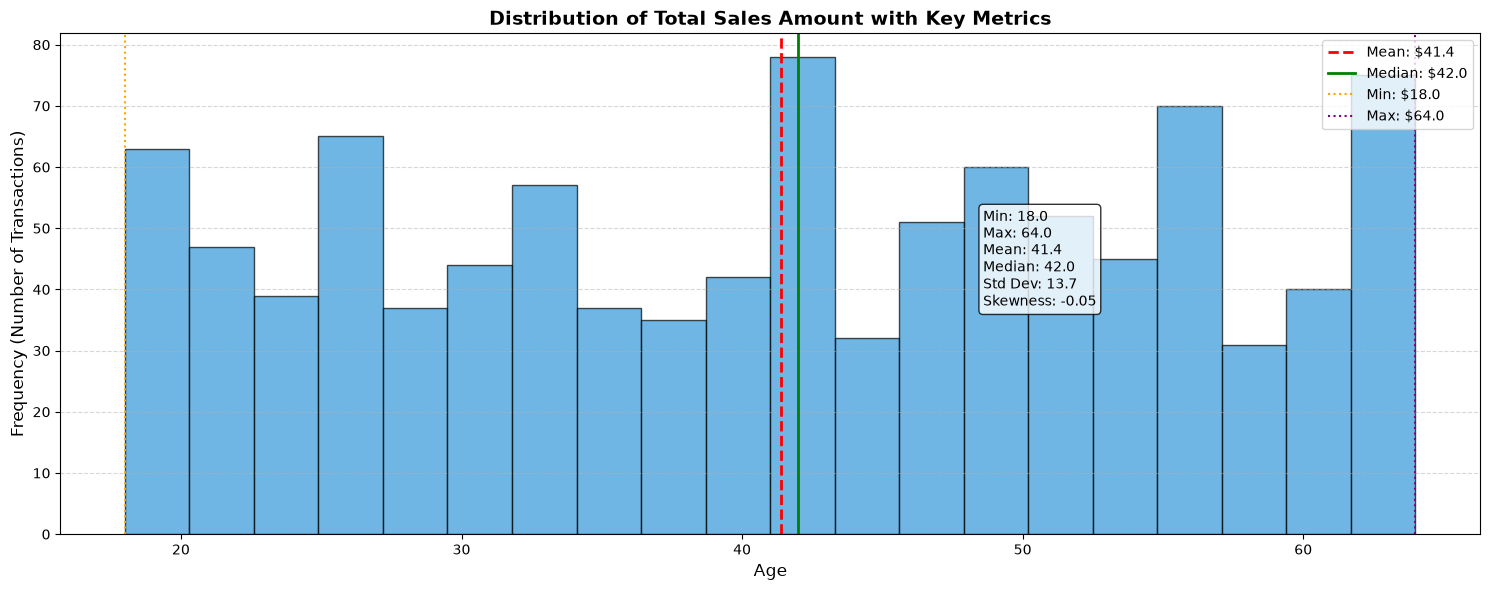

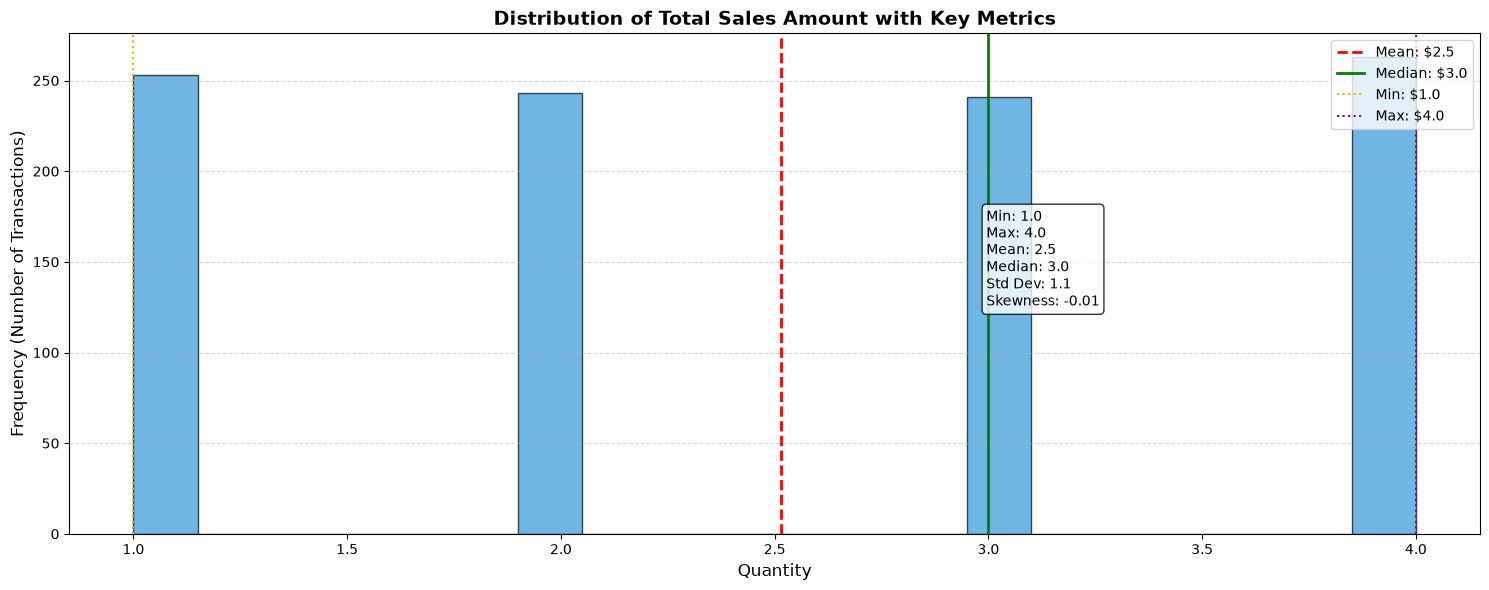

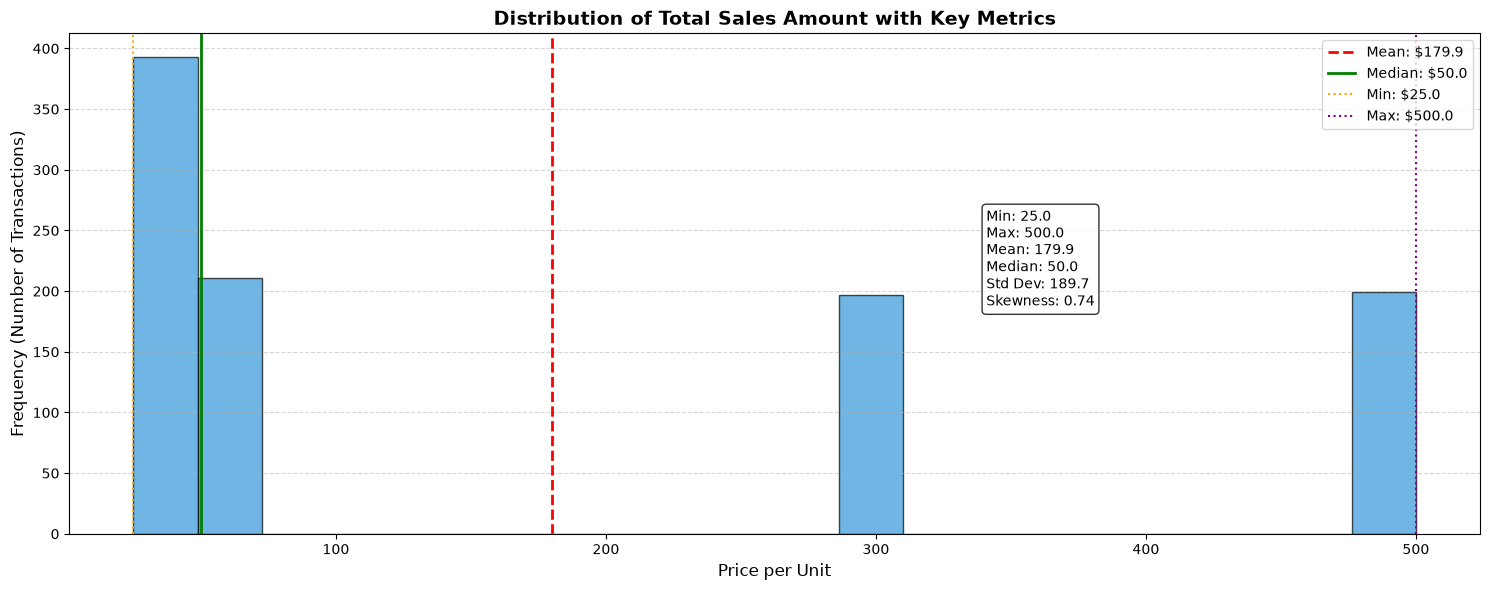

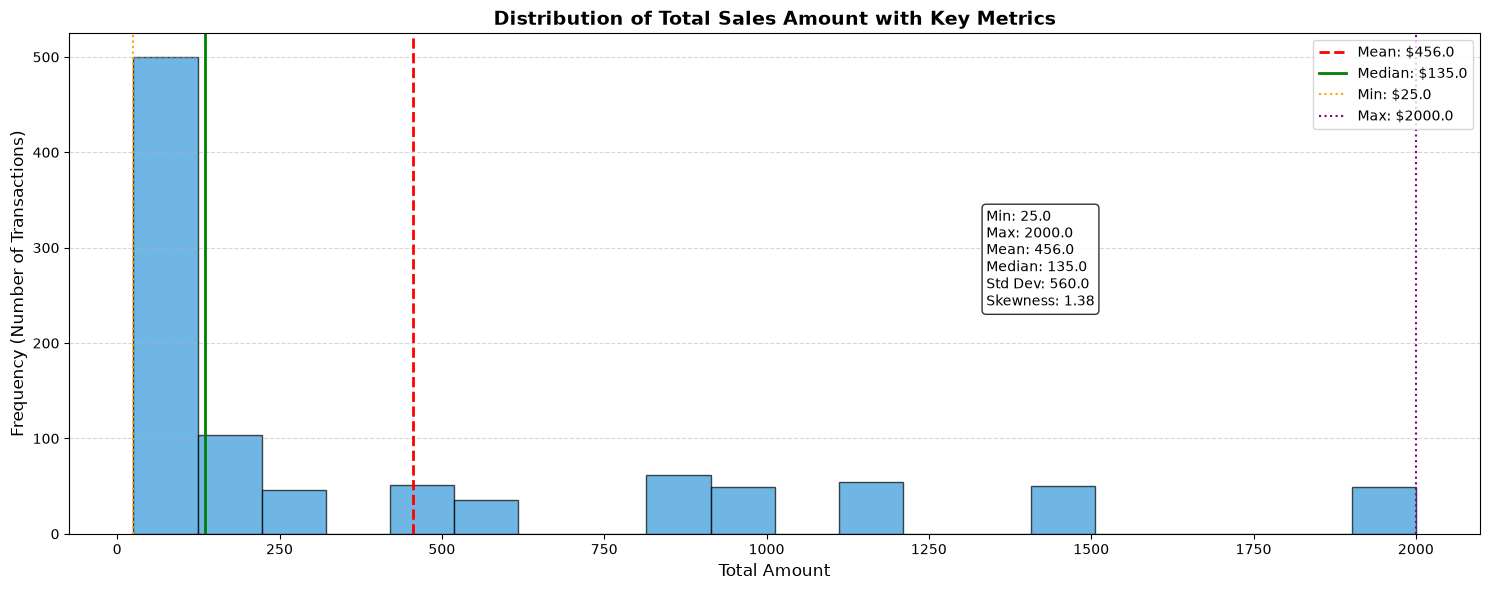

In [14]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        if col == "Transaction ID":
            continue
        else:
            # Figure and Axis create karein
            plt.figure(figsize=(15, 6))

            # 1. Histogram plot karein (Bins = 20)
            n, bins, patches = plt.hist(df[col], bins=20, color='#3498db', edgecolor='black', alpha=0.7)

            # 2. Key Statistical Lines Add Karein
            mean_val = df[col].mean()
            median_val = df[col].median()
            min_val = df[col].min()
            max_val = df[col].max()
            skew_val = df[col].skew()

            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:.1f}')
            plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: ${median_val:.1f}')
            plt.axvline(min_val, color='orange', linestyle=':', linewidth=1.5, label=f'Min: ${min_val:.1f}')
            plt.axvline(max_val, color='purple', linestyle=':', linewidth=1.5, label=f'Max: ${max_val:.1f}')

            # 3. Statistics Summary Box Overlay Karein
            stats_text = (f"Min: {min_val:.1f}\n"
                        f"Max: {max_val:.1f}\n"
                        f"Mean: {mean_val:.1f}\n"
                        f"Median: {median_val:.1f}\n"
                        f"Std Dev: {df[col].std():.1f}\n"
                        f"Skewness: {skew_val:.2f}")

            plt.gca().text(0.65, 0.65, stats_text, transform=plt.gca().transAxes, fontsize=10,
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            # 4. Labels and Title Formatting
            plt.title('Distribution of Total Sales Amount with Key Metrics', fontsize=14, fontweight='bold')
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Frequency (Number of Transactions)', fontsize=12)
            plt.legend(loc='upper right')
            plt.grid(axis='y', linestyle='--', alpha=0.5)

            plt.tight_layout()
            plt.show()

### 2. Heatmap 

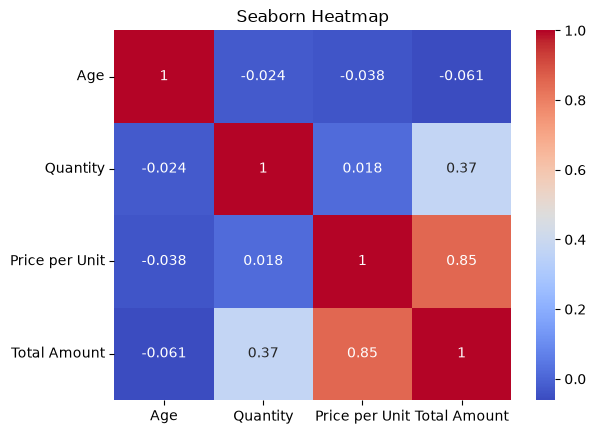

In [15]:
import seaborn as sns


# Sirf ye 1 line heatmap banayegi
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Seaborn Heatmap")
plt.show()

# 3. Charts

### 1. Age Distribution (Histogram with KDE)

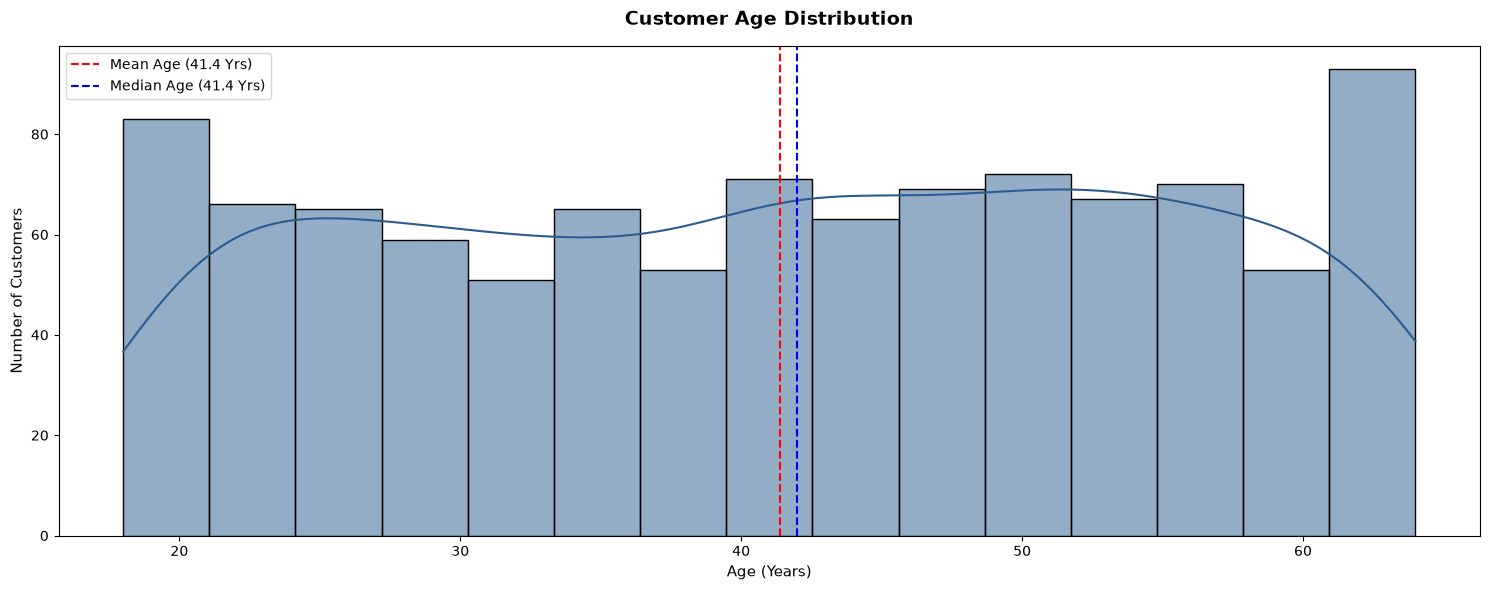

In [16]:
plt.figure(figsize=(15, 6))

sns.histplot(
    df['Age'],
    kde=True,
    color='#2b5c8f',
    bins=15
)

# Customizing plot
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)

# Mean age line grid view ke saath
mean_age = df['Age'].mean()
median_age = df['Age'].median()

plt.axvline(
    mean_age,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean Age ({mean_age:.1f} Yrs)'
)

plt.axvline(
    median_age,
    color='blue',
    linestyle='--',
    linewidth=1.5,
    label=f'Median Age ({mean_age:.1f} Yrs)'
)

plt.legend()
plt.tight_layout()
plt.show()

### Age Distribution Analysis:

- The store receives a maximum customer age of 60+ years, while both the median age and the mean age are centered around 40 years.

- This indicates an even distribution of customers across all age groups, with no significant outliers present.

### 2. Gender-wise Category Spending

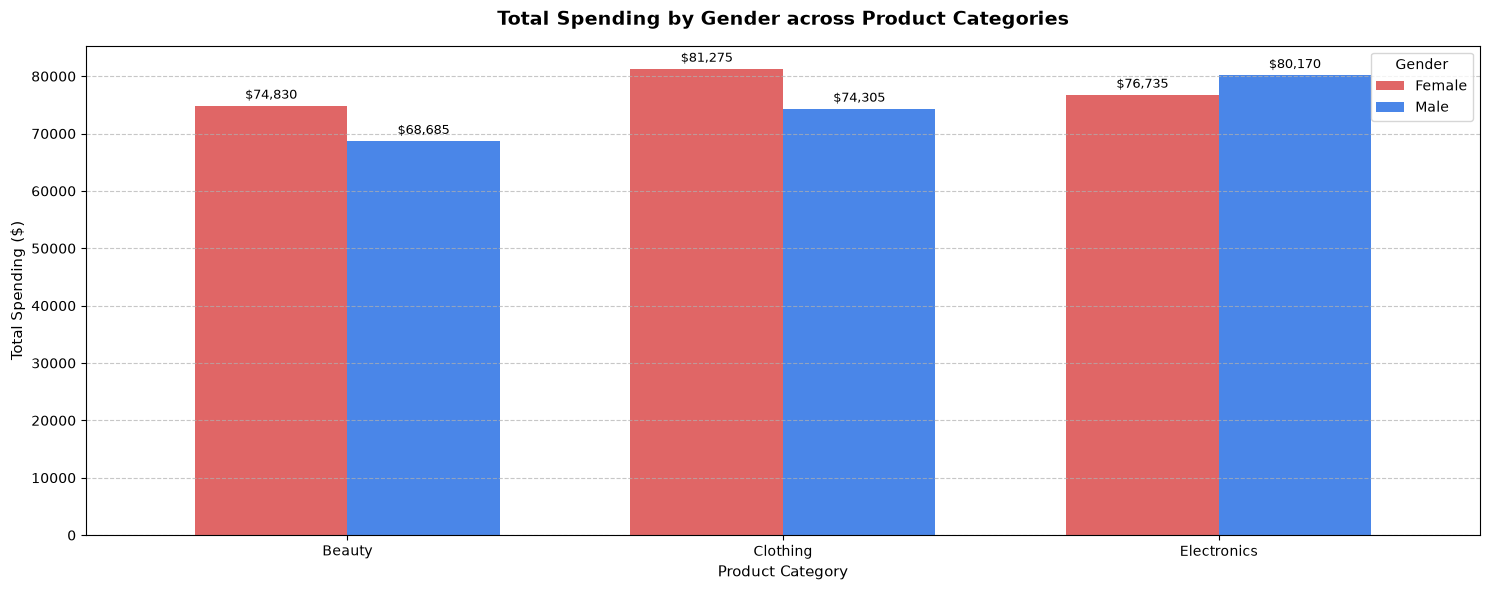

In [17]:

# Data aggregation: Gender and Category wise Total Amount sum
gender_category = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()

# Plotting Grouped Bar Chart using Matplotlib
fig, ax = plt.subplots(figsize=(15, 6))

gender_category.plot(
    kind='bar',
    ax=ax,
    color=['#e06666', '#4a86e8'],  # Female, Male colors
    width=0.7
)

# Customizing chart
plt.title('Total Spending by Gender across Product Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Spending ($)', fontsize=11)
plt.xticks(rotation=0)  # Labels straight bilkul readable rahenge
plt.legend(title='Gender', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Data values (labels) bars ke upar add karne ke liye
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'${int(p.get_height()):,}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

### Category Spending by Gender:

- Female customers spend more in the Beauty and Clothing categories.

- Male customers lead in overall spending within the Electronics category.

### 3. Product Performance & Basket Size

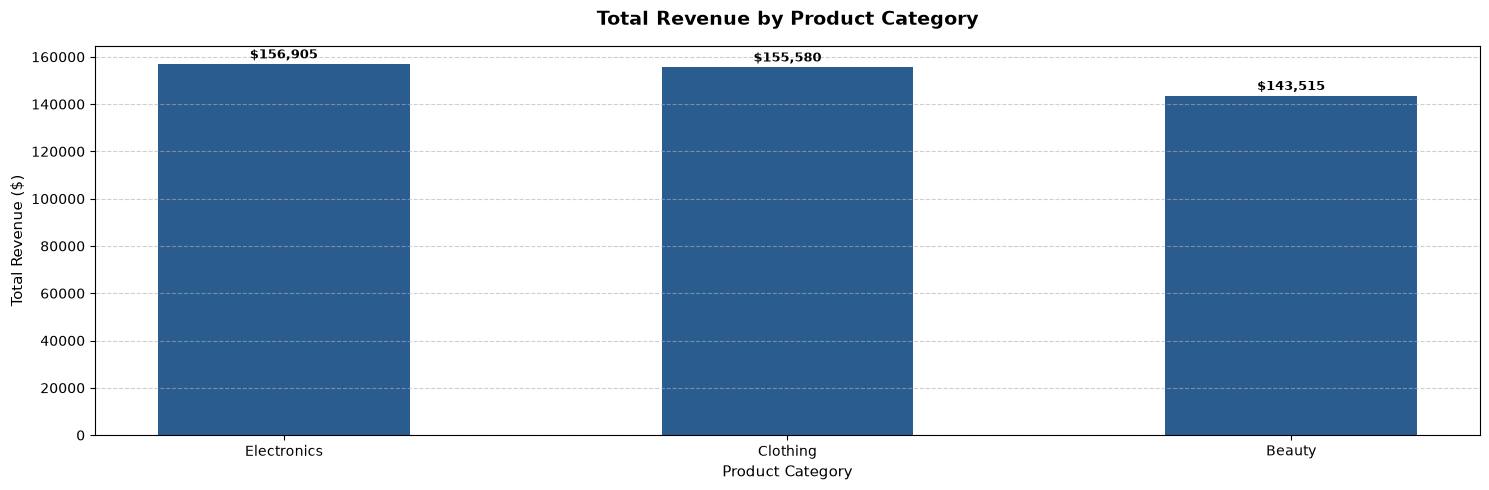

In [18]:
# Data Aggregation: Category-wise Revenue Calculation & Sorting
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Plotting
fig, ax = plt.subplots(figsize=(15, 5))

# Primary Bar Plot
bars = ax.bar(
    category_revenue.index,
    category_revenue.values,
    color="#2b5c8f",
    width=0.5,
)

# Title & Labels
plt.title(
    "Total Revenue by Product Category", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Adding exact values above bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"${int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 2),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### Product Category Revenue Analysis:

- Electronics generates the highest total revenue ($156,905), closely followed by Clothing ($155,580), while Beauty ranks third ($143,515).

- The top performance of Electronics is driven by higher item prices (higher ticket value) per transaction.

### 4. Outlier & Range Detection

1. Price per Unit & Total Amount

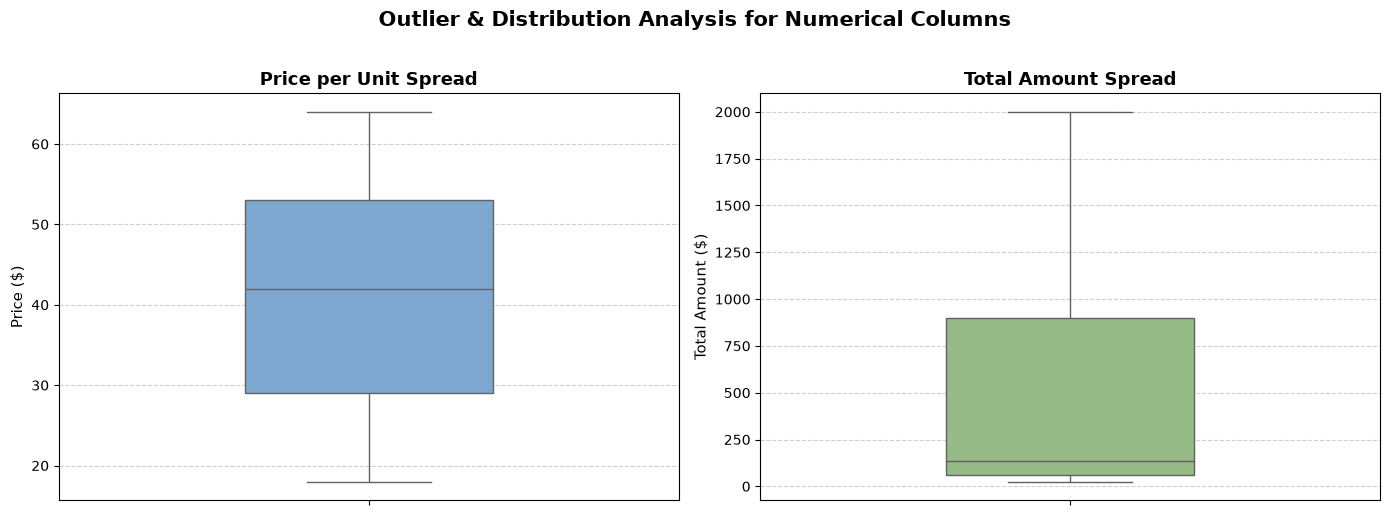

In [24]:
# Side-by-Side Plots ke liye Canvas Setup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Price per Unit Boxplot
sns.boxplot(y=df['Age'], ax=axes[0], color='#6fa8dc', width=0.4)
axes[0].set_title('Price per Unit Spread', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# 2. Total Amount Boxplot
sns.boxplot(y=df['Total Amount'], ax=axes[1], color='#93c47d', width=0.4)
axes[1].set_title('Total Amount Spread', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Amount ($)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Outlier & Distribution Analysis for Numerical Columns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Outlier & Distribution Analysis (Price per Unit vs Total Amount):

- Price per Unit: Demonstrates a highly balanced and uniform distribution spanning from $18 to $64, with a median unit price of approximately $42. No statistical outliers are observed in individual product pricing.

- Total Transaction Amount: Displays a right-skewed distribution where the median transaction value sits at ~$135, with 50% of total bills ranging between $60 and $900. High-value orders reach up to $2,000 due to multi-unit quantity purchases, without generating extreme statistical anomalies.

2. Category-wise Total Amount Distribution

C:\Users\ymjmr\AppData\Local\Temp\ipykernel_20300\3360405351.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


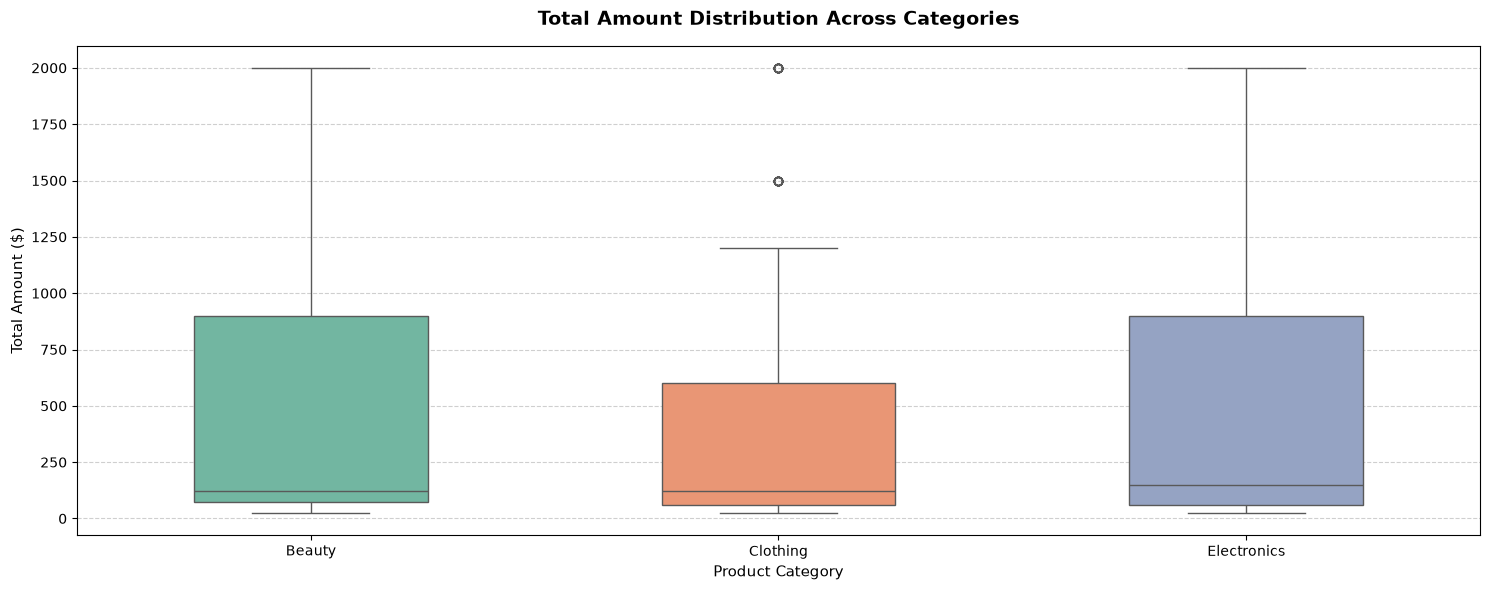

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))

# Category-wise Boxplot
sns.boxplot(
    data=df,
    x='Product Category',
    y='Total Amount',
    palette='Set2',
    ax=ax,
    width=0.5
)

plt.title('Total Amount Distribution Across Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Amount ($)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Total Amount Distribution Across Categories:

- Beauty & Electronics: Both categories exhibit a wider interquartile range (IQR) spanning up to $900, with maximum transaction values reaching $2,000. No statistical outliers are observed in either category, reflecting high variance driven by bulk or premium purchases.

- Clothing: Exhibits a lower overall spending concentration, with the main box limited to ~$600 and the upper whisker extending to $1,200. Unlike the other two categories, Clothing displays two distinct statistical outliers at $1,500 and $2,000, representing unusually large basket sizes.

- Median Comparison: All three product categories maintain low and similar median spending levels (~$120 - $150), confirming that most individual retail transactions across all segments remain budget-friendly.

### 5. Time-Based Patterns

1. Monthly Sales Trend

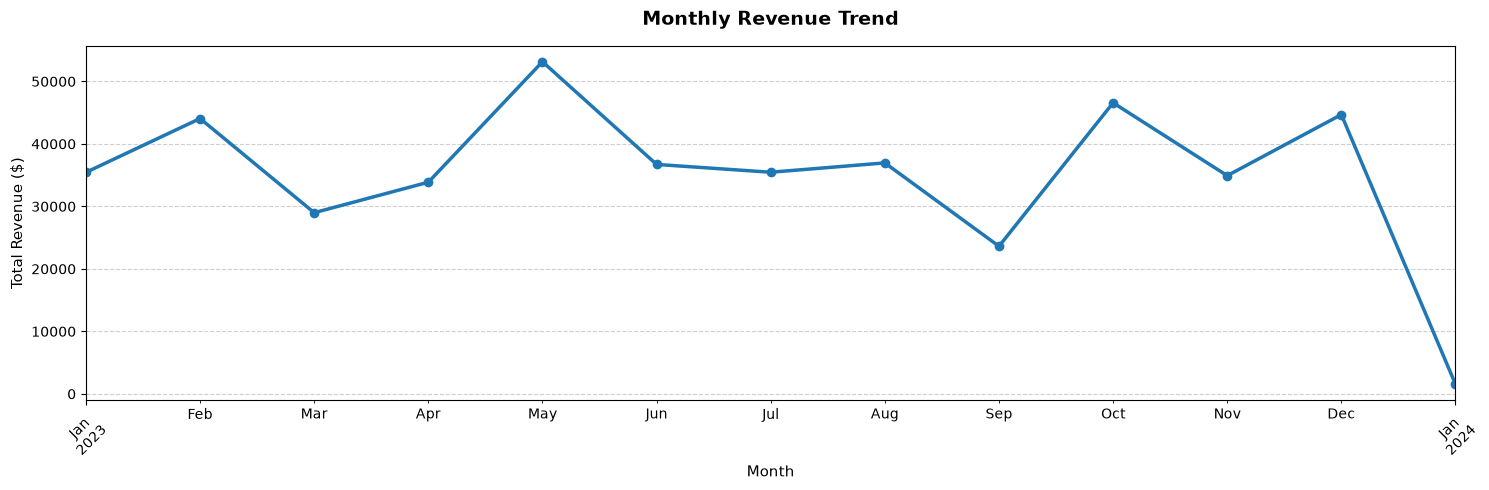

In [21]:
# Monthly Sales Aggregation
df["YearMonth"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("YearMonth")["Total Amount"].sum()

# Plotting
fig, ax = plt.subplots(figsize=(15, 5))

monthly_sales.plot(
    kind="line", marker="o", color="#1f77b4", linewidth=2.5, ax=ax
)

# Formatting
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Monthly Revenue Trend:

- Peak Sales Performance: Monthly revenue reaches its highest peak in May (~$53,000), followed by strong secondary peaks in October (~$46,500) and December (~$44,500), indicating seasonal demand spikes.

- Revenue Dip: The lowest sales period occurs in September (~$23,500), showing a temporary drop in purchasing activity before the Q4 surge.

2. Sales by Day of the Week

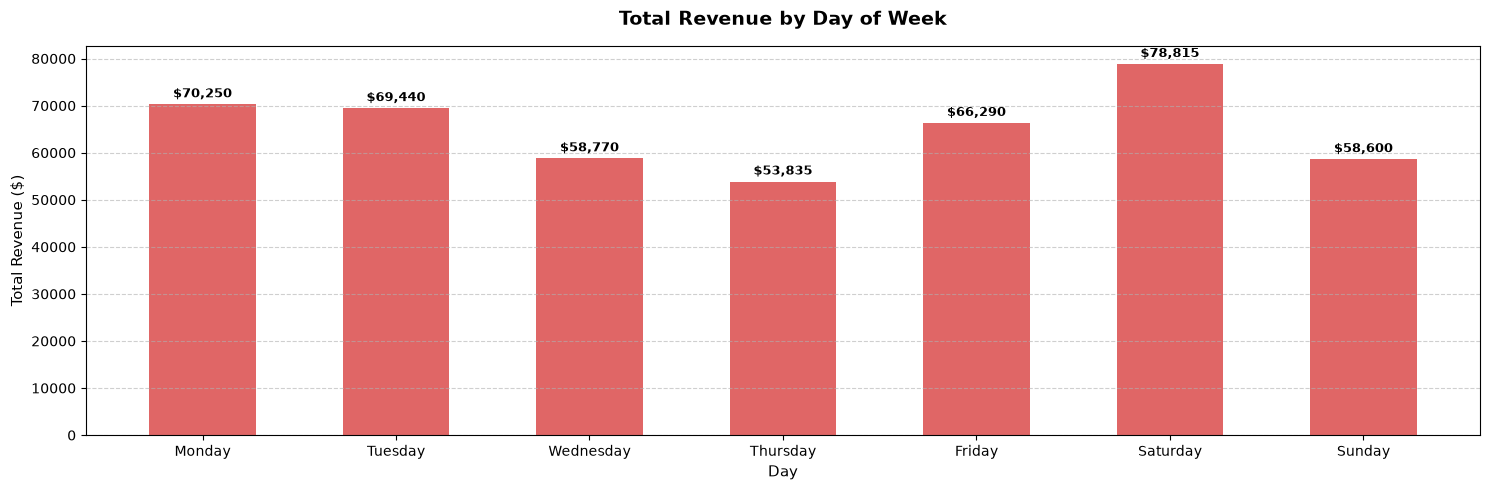

In [22]:
# Day Name Extract Karna aur Order Set Karna
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
df["DayOfWeek"] = df["Date"].dt.day_name()
daily_sales = df.groupby("DayOfWeek")["Total Amount"].sum().reindex(day_order)

# Plotting
fig, ax = plt.subplots(figsize=(15, 5))

bars = ax.bar(daily_sales.index, daily_sales.values, color="#e06666", width=0.55)

plt.title("Total Revenue by Day of Week", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Values above bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"${int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### Total Revenue by Day of Week:

- Peak Sales Day: Saturday generates the highest overall revenue at $78,815, reflecting strong weekend purchasing behavior.

- Mid-Week Dip: Revenue experiences a steady decline through the middle of the week, reaching its lowest point on Thursday ($53,835) before recovering on Friday ($66,290).

- Early Week Strength: Monday ($70,250) and Tuesday ($69,440) perform surprisingly well, indicating significant early-week shopping momentum alongside the weekend peak.

## Final Business Insights & Recommendations


1. Cross-Selling & Basket Expansion Opportunity:
While Electronics leads in total revenue ($156.9k) driven by high unit prices, Clothing matches its revenue performance ($155.5k) through higher transaction volume. Bundling complementary clothing items with electronics purchases (e.g., tech accessories or carrying cases) can further boost overall basket value.

2. High-Value Outlier Targeting in Clothing:
Clothing transactions naturally cap at ~$1,200, yet show distinct high-value outliers up to $2,000. These represent rare bulk or premium purchases. Implementing a structured loyalty program or wholesale/bulk pricing tiers can help convert these occasional high-value buyers into recurring customers.

3. Capitalizing on Early-Week Shopping Momentum:
Beyond expected Saturday revenue peaks ($78.8k), Monday ($70.2k) and Tuesday ($69.4k) generate surprisingly strong sales compared to mid-week slumps (Thursday low at $53.8k). Marketing campaigns and promotional emails should be scheduled for Sunday evening or Monday morning to capture this early-week demand.

4. Mitigating Q3 Revenue Slumps:
Sales reach a major peak in May ($53k) before dropping significantly to an annual low in September ($23.5k) right before the Q4 holiday surge. Introducing mid-year clearance sales or end-of-summer promotional events in August–September can help stabilize revenue cash flows.

5. Targeted Inventory & Marketing Strategies:
Demographic data shows female buyers spend heavily in Beauty and Clothing, while male buyers drive Electronics revenue. Personalized recommendation engines on the store platform should leverage these demographic spending preferences for targeted product marketing.